# Polarity separability of bipolar narratives (Evergreen_v5, RavenBERT)

The Covid notebook's pole-leakage diagnostic shows the two poles of a bipolar dimension co-moving
(weekly θ̄ correlation up to 0.98). Two readings:

- **topic-only scorer**: cosine similarity on RavenBERT finds the dimension but cannot tell the
  direction, so both poles light up together;
- **aggregation artefact**: direction is visible per headline, but gets smeared by pooling and weekly
  averaging.

This notebook separates the two with a controlled test set: **30 bipolar pairs × 2 poles × 5
synthetic headlines = 300 headlines** with known ground truth, scored against the full taxonomy.

| test | question |
|---|---|
| A. primitive geometry | Before any headline: how close are pole A and pole B texts to each other, vs unrelated narratives? |
| B. minimal pairs | "Fed signals rate **hikes**" vs "Fed signals rate **cuts**": how close are the two headline embeddings? |
| C. pole contest | Per headline: does mean-top-K(correct pole) beat mean-top-K(opposite pole)? Accuracy, margin, AUC of the signed difference. |
| D. by headline kind | minimal / plain / negation / contrast: does negation or opposite-pole wording fade away or flip the call? |
| E. topic vs direction | Rank of both poles among all narratives: is the dimension found even when the direction is wrong? |
| F. production selection | Production candidate budget ceil((1−q)·P) (+ optional τ, + jump cut if the run used it): is the correct pole selected, the opposite, or both? |

Everything runs for `raw`, `R1`, `R2`. Read-only on the datalake; writes nothing unless `SAVE_DIR` is set.

Headline kinds (same order for every pole): `minimal` (minimal edit of the other pole's minimal
headline), `plain` ×2, `negation` (pole expressed by negating / ending the opposite state), `contrast`
(opposite state mentioned as past context, current direction = this pole).

In [1]:
import os, re, json
from datetime import date
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from dotenv import find_dotenv, load_dotenv

from datalake import DatalakeIndex
from narrative_scoring.artifacts import load_registered_table
from narrative_scoring.calibration import load_mu_asof, resolve_mu_asof
from narrative_scoring.config import AggRule, ScoringConfig, n_candidates_for
from narrative_scoring.corrections import Correction, apply_mode, l2_normalise
from narrative_scoring.primitives import embed_primitive_texts, sanity_checks
from narrative_scoring.selection import select
from ravenpack.headlines.embed import load_embedding_model

load_dotenv(find_dotenv(usecwd=True))
pl.Config.set_tbl_rows(60); pl.Config.set_tbl_width_chars(220); pl.Config.set_fmt_str_lengths(90)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "figure.constrained_layout.use": True})

# ---- artifacts --------------------------------------------------------------------------
TAXONOMY = "Evergreen_v5"
NARRATIVE_DAILY_ID = None     # None = most recent narrative_daily of TAXONOMY; its run config drives the scoring
MU_ASOF_ID = None             # None = the mu_asof artifact the narrative_daily run used
MU_DATE = None                # None = last available row; else a date, as-of that day
CACHE_DIR = Path(os.environ["CACHE_PATH"]) / "narrative_scoring"   # production primitive-text embedding cache

# ---- encoder ------------------------------------------------------------------------------
EMBED_DEVICE = "embedx"       # production backend; "cuda"/"cpu" loads RavenBERT locally from RAVENBERT_DIR
RAVENBERT_DIR = os.environ.get("RAVENBERT_EMBEDDING_MODEL_PATH", ".")
BATCH = 128
CHECK_ENCODER = True          # re-embed stored headlines and compare with headline_embeddings

# ---- scoring --------------------------------------------------------------------------------
MODES = ("raw", "r1", "r2")
K_LIST = (1, 2, 3, 5, None)   # pole score = mean of its top-K primitive scores; None = all primitives
K_MAIN = 3
PARAPHRASE_POOLING = None     # None = take it from the narrative_daily config ("max" / "mean" / "median")
MAIN_MODE = None              # None = take it from the narrative_daily config
Q_ROW = None                  # None = take it from the narrative_daily config (row-wise percentile)
TAU = None                    # optional absolute floor for test F (per mode dict or float); None = percentile only
TOPN = 10                     # "found" = narrative within the top-N of all narratives (test E)

SAVE_DIR = None               # e.g. Path("~/tmp/polarity").expanduser() to dump result tables
RNG = np.random.default_rng(0)


## 0. Resolve the scoring configuration and the taxonomy


In [2]:
dl = DatalakeIndex(os.environ["DATALAKE_ROOT"], create=False)
up_root = os.environ.get("DATALAKE_UPSTREAM_ROOT")
up = DatalakeIndex(up_root, create=False) if up_root else dl
LAKES = (dl, up)


def get_art(artifact_id):
    return next(x for x in LAKES if x.exists(artifact_id)).get(artifact_id)


def newest(kind, pred=lambda a: True):
    for x in LAKES:
        c = [a for a in x.list(kind, include_partial=True) if not a.deprecated and pred(a)]
        if c:
            return c[0]
    raise LookupError(f"no {kind} artifact")


ND = get_art(NARRATIVE_DAILY_ID) if NARRATIVE_DAILY_ID else newest(
    "narrative_daily", lambda a: a.meta.hyperparams.get("taxonomy_name") == TAXONOMY)
hp = ND.meta.hyperparams
RUN_META = json.loads((ND.path / "run_metadata.json").read_text())
CFG = ScoringConfig(**RUN_META["config"])
MAIN_MODE = (MAIN_MODE or CFG.mode.value).lower()
PARAPHRASE_POOLING = PARAPHRASE_POOLING or CFG.paraphrase_pooling.value
Q_ROW = Q_ROW if Q_ROW is not None else CFG.q
print("scoring config from", ND.artifact_id)
print({k: hp.get(k) for k in ("taxonomy_name", "taxonomy_artifact_id", "config_id")} | CFG.to_dict())
print(f"-> MAIN_MODE={MAIN_MODE}  PARAPHRASE_POOLING={PARAPHRASE_POOLING}  Q_ROW={Q_ROW}")

TAX = get_art(hp["taxonomy_artifact_id"])
table = load_registered_table(TAX, CFG.paraphrase_style.value, include_master=CFG.include_master)
print(f"\ntaxonomy artifact {TAX.artifact_id}: style {table.style}, "
      f"{table.n_texts} texts per primitive (master {'included' if CFG.include_master else 'excluded'})")
sanity_checks(table)


scoring config from narrative_daily__v2.1.0__params9a98bad9__20260923
{'taxonomy_name': 'Evergreen_v5', 'taxonomy_artifact_id': 'narrative_taxonomy__v2.1.0__paramsbf25ede9__20260923', 'config_id': '6e35b0daf39b6d94', 'mode': 'r2', 'paraphrase_style': 'headline', 'paraphrase_pooling': 'max', 'q': 0.99, 'narrative_agg': 'mean', 'jump_cut': False, 'jump_min_candidates': 10, 'alpha': 0.01, 'trim_frac': 0.1, 'include_master': True, 'null_draws_per_headline': 64, 'min_month_draws': 20000000, 'gap_alert_threshold': 0.05, 'sentiment_split': 'none', 'neutral_eps': 0.0, 'sentiment_source': 'none', 'sentiment_column': '', 'label': ''}
-> MAIN_MODE=r2  PARAPHRASE_POOLING=max  Q_ROW=0.99

taxonomy artifact narrative_taxonomy__v2.1.0__paramsbf25ede9__20260923: style headline, 6 texts per primitive (master included)


check,result,detail
str,str,str
"""1. primitive key uniqueness""","""PASS""","""1508 primitives, 0 duplicate key(s) on ('TOPIC', 'GROUP', 'CATEGORY', 'ROLE', 'OBSERVABILI…"
"""2. CSV<->JSONL bijection (sha1 path hash)""","""PASS""","""1508 primitives joined on path_id; enforced in load_primitive_table"""
"""3. uniform K paraphrases""","""PASS""","""K=5; 6 text(s) per primitive (master included)"""
"""6. bipolar mirror presence""","""REVIEW""","""184 signed narratives; 11 dimension(s) carry exactly one signed narrative (candidate orpha…"


In [3]:
# production PrimitiveTable -> the taxonomy column names used below; PRIM = score column, NARR = narrative_id
tax = table.frame.select(
    pl.col("primitive_id").cast(pl.Int64).alias("PRIM"), pl.col("narrative_id").cast(pl.Int64).alias("NARR"),
    pl.col("reservoir").alias("TOPIC"), pl.col("dimension").alias("GROUP"), pl.col("narrative").alias("CATEGORY"),
    pl.col("TYPE").fill_null(""), pl.col("pole").fill_null("").alias("SUB_TYPE"),
).sort("PRIM")
NKEY = ["TOPIC", "GROUP", "CATEGORY"]          # narrative = scoped (reservoir, dimension, narrative)
narr = table.narrative_frame.select(
    pl.col("narrative_id").cast(pl.Int64).alias("NARR"), pl.col("reservoir").alias("TOPIC"),
    pl.col("dimension").alias("GROUP"), pl.col("narrative").alias("CATEGORY"),
).sort("NARR")
assert (narr["NARR"].to_numpy() == np.arange(narr.height)).all()
print(f"{tax.height} primitives | {narr.height} narratives | {tax['GROUP'].n_unique()} dimensions | "
      f"{tax['TOPIC'].n_unique()} reservoirs")


1508 primitives | 419 narratives | 90 dimensions | 11 reservoirs


Primitive texts come from the production loader (`load_registered_table`), which enforces the CSV <->
JSONL sha1 path-hash bijection and uniform K. `table.texts` is primitive-major: primitive `i` owns texts
`[i*n_texts, (i+1)*n_texts)`, master first when the run included it.


In [4]:
K_PARA, N_TXT = table.k_paraphrases, table.n_texts
T_TEXT = table.texts
T_PRIM = np.repeat(np.arange(table.n_primitives), N_TXT)
PRIM_START = np.arange(0, len(T_TEXT), N_TXT)                  # reduceat offsets
PRIM_NARR = tax["NARR"].to_numpy()
print(f"uniform K = {K_PARA} | {len(T_TEXT):,} primitive texts ({tax.height} x {N_TXT})")


uniform K = 5 | 9,048 primitive texts (1508 x 6)


## 1. Encoder (RavenBERT, production backend) and the point-in-time mean direction


In [5]:
MODEL = load_embedding_model(Path(RAVENBERT_DIR), device=EMBED_DEVICE)
print("encoder:", type(MODEL).__name__, "| device:", EMBED_DEVICE)


def embed(texts):
    return l2_normalise(np.asarray(MODEL.encode(list(texts), batch_size=BATCH), dtype=np.float32))


encoder: RemoteEmbeddingModel | device: embedx


In [6]:
# encoder check: re-embed stored headlines, compare with the production headline_embeddings
if CHECK_ENCODER:
    try:
        EA = newest("headline_embeddings")
        HA = newest("ravenpack_headlines")
        months = sorted({p.stem for p in Path(EA.path).glob("*.parquet")} &
                        {p.stem for p in Path(HA.path).glob("*.parquet")})
        m = months[len(months) // 2]
        emb = pl.read_parquet(Path(EA.path) / f"{m}.parquet")
        hed = pl.read_parquet(Path(HA.path) / f"{m}.parquet")
        tcol = next(c for c in hed.columns if "HEADLINE" in c.upper() and hed.schema[c] == pl.Utf8)
        j = (hed.select("RP_STORY_ID", tcol).join(emb, on="RP_STORY_ID")
             .filter(pl.col(tcol).str.len_chars() > 20).head(256))
        ref = l2_normalise(j["EMBEDDING"].to_numpy())
        mine = embed(j[tcol].to_list())
        c = (ref * mine).sum(1)
        print(f"encoder check on {len(c)} headlines of {m} (column {tcol}): "
              f"cos mean {c.mean():.4f} | min {c.min():.4f}")
        if c.mean() < 0.99:
            print("WARNING: this encoder does not reproduce the stored embeddings: check EMBED_DEVICE / weights")
    except Exception as e:                      # never block the study on the check
        print("encoder check skipped:", repr(e))

encoder check on 256 headlines of 2013-01 (column HEADLINE): cos mean 0.9999 | min 0.9999


In [7]:
MU_ART = get_art(MU_ASOF_ID or RUN_META["mu_asof_id"])
mu_df = load_mu_asof(next(MU_ART.path.glob("*.parquet")))
mu_ref = resolve_mu_asof(mu_df, MU_DATE or mu_df["DATE"].max())
MU, U = mu_ref.mu, mu_ref.mu_hat
n_mu = mu_df.filter(pl.col("DATE") == mu_ref.date)["N"][0]
print(f"mu from {MU_ART.artifact_id} as of {mu_ref.date} (N={n_mu:,}) | ||mu|| = {np.linalg.norm(MU):.4f}")


def correct(X, mode):
    # production step 1: L2, raw / R1 / R2, renormalise (same mu for headlines and primitive texts)
    return apply_mode(X, Correction(mode), MU, U)


mu from mu_asof__v0.1.0__delay1M_dim384_modeexpanding_source_embeddings22eff164_source_headlines901917c7__20260913 as of 2025-12-31 (N=991,564,116) | ||mu|| = 0.5539


## 2. Test set: 30 bipolar pairs, 5 headlines per pole

In [8]:
# ---- test set: 30 bipolar pairs x 2 poles x 5 headlines = 300 headlines --------------------------
# Each pole lists candidate narrative names (first one found in the taxonomy wins).
# Headline kinds, same order for every pole:
#   minimal  : minimal edit of the other pole's "minimal" headline (only the direction words change)
#   plain    : direct statement of the pole
#   plain    : direct statement of the pole
#   negation : the pole expressed by negating / ending the opposite state
#   contrast : mentions the opposite state as past context, current direction = this pole
KINDS = ("minimal", "plain", "plain", "negation", "contrast")

PAIRS = [
    dict(pair="political-power-tenure",
         a=["mandate-strengthening"], b=["mandate-weakening"],
         A=["Prime minister's coalition wins outright majority in snap election",
            "President's approval rating climbs to two-year high after reform package",
            "Ruling party expands parliamentary majority in regional elections",
            "No-confidence motion against chancellor defeated by wide margin",
            "Despite early losses, governing party emerges from midterms with stronger mandate"],
         B=["Prime minister's coalition loses outright majority in snap election",
            "President's approval rating sinks to record low amid scandal",
            "Senior ministers resign, leaving premier's government on brink of collapse",
            "Ruling party no longer commands a majority after defections",
            "Weeks after landslide win, premier's authority crumbles as party revolts"]),
    dict(pair="labour-market-slack",
         a=["labour-market-tightening"], b=["labour-market-slackening"],
         A=["US unemployment rate falls to 3.5%, lowest in five decades",
            "Job openings hit record as employers struggle to fill vacancies",
            "Wage growth accelerates as companies compete for scarce workers",
            "Jobless claims no longer rising, drop to lowest since 2019",
            "Layoff fears fade as payrolls beat forecasts for third straight month"],
         B=["US unemployment rate rises to 5.5%, highest in five years",
            "Initial jobless claims jump as layoffs spread across manufacturing",
            "Hiring freezes widen and job openings fall to three-year low",
            "Employers no longer struggling to find workers as applications pile up",
            "After years of labour shortages, job market cools sharply as layoffs mount"]),
    dict(pair="cross-border-monetary-conditions",
         a=["global-liquidity-easing"], b=["global-liquidity-tightening"],
         A=["Global central banks inject liquidity as dollar funding conditions ease",
            "Fed expands dollar swap lines with major central banks",
            "Emerging markets see record capital inflows as global liquidity loosens",
            "Dollar squeeze ends as global funding strains no longer bite",
            "After last year's tightening, central banks flood markets with cash again"],
         B=["Global central banks drain liquidity as dollar funding conditions tighten",
            "Strong dollar and Fed balance sheet runoff squeeze global liquidity",
            "Emerging markets hit by capital outflows as global financial conditions tighten",
            "Era of cheap global money is over as central banks stop reinvesting",
            "Liquidity glut unwinds as synchronized quantitative tightening begins"]),
    dict(pair="public-health-condition",
         a=["public-health-improvement"], b=["public-health-deterioration"],
         A=["Hospital admissions fall sharply as infection wave recedes",
            "WHO says new cases declining for fifth consecutive week",
            "Vaccination campaign drives death rate to lowest level since outbreak",
            "Health officials say virus no longer spreading in most regions",
            "After winter surge, infections plunge and intensive care units empty out"],
         B=["Hospital admissions rise sharply as infection wave spreads",
            "WHO warns new cases climbing for fifth consecutive week",
            "Death toll surges as outbreak overwhelms health systems",
            "Health officials say outbreak is no longer under control",
            "Weeks after easing, infections rebound and intensive care units fill again"]),
    dict(pair="policy-guidance-and-reaction-function",
         a=["hawkish-guidance-shift"], b=["dovish-guidance-shift"],
         A=["Fed signals more rate hikes ahead to tame inflation",
            "ECB's Lagarde says policy must stay restrictive for longer",
            "Fed minutes show officials see need for higher rates",
            "Powell rules out rate cuts this year, says inflation fight not over",
            "Markets bet on cuts, but Fed chair pushes back and flags further tightening"],
         B=["Fed signals rate cuts ahead as inflation cools",
            "ECB's Lagarde opens door to easing as growth weakens",
            "Fed minutes show officials see scope to lower rates",
            "Powell says further rate hikes are no longer needed",
            "Despite hot inflation print, Fed chair signals patience and possible cuts"]),
    dict(pair="aggregate-corporate-profitability",
         a=["profit-cycle-upturn"], b=["margin-compression"],
         A=["S&P 500 profit margins expand to record as costs ease",
            "Corporate earnings growth accelerates across sectors",
            "Aggregate US corporate profits rise at fastest pace in a decade",
            "Margin squeeze fears fade as companies pass on higher prices",
            "After two years of shrinking margins, corporate profitability rebounds"],
         B=["S&P 500 profit margins shrink as costs rise",
            "Rising wages and input costs squeeze corporate margins",
            "Companies warn of thinner margins as pricing power fades",
            "Firms can no longer pass on cost increases, eroding profitability",
            "Revenue holds up but margins compress as costs outpace prices"]),
    dict(pair="fiscal-tax-policy-direction",
         a=["fiscal-easing-decision"], b=["fiscal-tightening-decision"],
         A=["Government approves tax cuts and higher spending in new budget",
            "Parliament passes $2 trillion stimulus package",
            "Finance minister unveils expanded infrastructure spending plan",
            "Treasury drops planned austerity measures, will not raise taxes",
            "Reversing course on austerity, government boosts spending"],
         B=["Government approves tax hikes and spending cuts in new budget",
            "Parliament passes austerity package to cut deficit",
            "Finance minister announces sweeping public spending cuts",
            "Treasury will not extend stimulus, lets support programs expire",
            "After years of stimulus, government turns to deficit reduction"]),
    dict(pair="equity-capital-actions",
         a=["share-buyback"], b=["equity-issuance"],
         A=["Siemens announces 5 billion euro share buyback",
            "Apple announces $90 billion share repurchase program",
            "Oil major boosts share buybacks on windfall cash flow",
            "Company scraps planned stock sale and will repurchase shares instead",
            "Instead of issuing new shares, firm returns cash through buybacks"],
         B=["Siemens announces 5 billion euro share sale",
            "Bank launches rights issue to shore up capital",
            "Startup raises $2 billion in follow-on equity offering",
            "Company suspends buyback program and plans new stock issuance",
            "After years of buybacks, carmaker turns to equity markets to raise cash"]),
    dict(pair="sovereign-solvency-condition",
         a=["debt-sustainability-improvement"], b=["debt-sustainability-deterioration"],
         A=["Italy's debt-to-GDP ratio falls as primary surplus widens",
            "Moody's upgrades Greece citing improving debt dynamics",
            "IMF says Egypt's public debt now on sustainable path",
            "Sovereign default fears recede as bond spreads narrow",
            "Once seen as insolvent, Portugal's debt burden steadily declines"],
         B=["Italy's debt-to-GDP ratio rises as deficit widens",
            "Moody's downgrades Italy citing worsening debt dynamics",
            "IMF warns Egypt's public debt is on unsustainable path",
            "Government can no longer cover interest bill without new borrowing",
            "Despite austerity pledges, UK debt burden climbs to 60-year high"]),
    dict(pair="intermediation-capacity (balance sheets)",
         a=["bank-balance-sheet-repair"], b=["bank-balance-sheet-impairment"],
         A=["Banks rebuild capital as bad loan ratios fall",
            "European lenders complete clean-up of non-performing loans",
            "Bank raises core capital ratio to 14% after asset sales",
            "Loan-loss provisions no longer rising as credit quality stabilises",
            "Years after crisis write-downs, bank balance sheets are healthy again"],
         B=["Banks lose capital as bad loan ratios rise",
            "Lenders take multibillion-dollar write-downs on mortgage securities",
            "Bank reports surge in non-performing loans and capital shortfall",
            "Bank's capital buffer no longer sufficient after trading losses",
            "After years of repair, banks face fresh wave of loan losses"]),
    dict(pair="intermediation-capacity (credit supply)",
         a=["credit-supply-expansion"], b=["credit-supply-tightening"],
         A=["Banks ease lending standards for business loans, Fed survey shows",
            "Lenders loosen credit terms as competition for borrowers heats up",
            "Mortgage availability rises as banks expand lending",
            "Banks no longer tightening loan standards, survey finds",
            "After credit squeeze, lenders reopen the taps to small businesses"],
         B=["Banks tighten lending standards for business loans, Fed survey shows",
            "Lenders cut credit lines and raise collateral requirements",
            "Mortgage availability falls as banks pull back lending",
            "Banks no longer willing to lend to small businesses",
            "After years of easy credit, lenders slam the brakes on loans"]),
    dict(pair="soft-landing / hard-landing",
         a=["soft-landing"], b=["hard-landing"],
         A=["Economists see US economy heading for soft landing",
            "Inflation cools without recession as growth holds up",
            "IMF says China can slow gradually without a sharp downturn",
            "Recession fears fade as economy avoids contraction",
            "Despite aggressive rate hikes, economy slows gently rather than crashes"],
         B=["Economists see US economy heading for hard landing",
            "Aggressive tightening set to push economy into deep recession",
            "IMF warns China faces sharp downturn as property slump deepens",
            "Hopes of a soft landing vanish as output collapses",
            "Rate hikes meant to slow growth gently now trigger recession"]),
    dict(pair="currency-regime-and-intervention",
         a=["peg-defence"], b=["devaluation-and-depreciation-tolerance"],
         A=["Central bank sells reserves to defend currency peg",
            "Hong Kong Monetary Authority intervenes to defend dollar peg",
            "Saudi central bank reaffirms commitment to riyal peg",
            "Central bank rules out devaluation, vows to hold exchange rate",
            "Despite heavy outflows, authorities refuse to let the currency slide"],
         B=["Central bank stops selling reserves and lets currency peg go",
            "Egypt devalues pound by 30% in shift to flexible exchange rate",
            "China allows yuan to weaken past 7 per dollar",
            "Central bank will no longer defend the currency, lets it float",
            "After years defending the peg, Nigeria allows naira to depreciate sharply"]),
    dict(pair="executive-legislative-capacity",
         a=["governing-capacity-restoration"], b=["legislative-gridlock"],
         A=["Congress passes budget deal, ending government shutdown",
            "Lawmakers reach bipartisan agreement on infrastructure bill",
            "New coalition government sworn in after months of deadlock",
            "Parliament no longer paralysed as parties agree on legislative agenda",
            "After months of stalemate, Senate passes debt ceiling bill"],
         B=["Congress fails to pass budget deal, government shuts down",
            "Lawmakers deadlocked as bipartisan talks on spending collapse",
            "Belgium still without government after months of coalition talks",
            "Parliament unable to pass any legislation as parties refuse to compromise",
            "Weeks after promising cooperation, Congress stalls on every major bill"]),
    dict(pair="sector-input-and-cost-condition",
         a=["input-cost-relief"], b=["input-cost-squeeze"],
         A=["Manufacturers get relief as raw material costs fall",
            "Freight rates and commodity prices drop, easing input costs",
            "Chipmakers see lower wafer and energy costs",
            "Input cost pressures no longer building as supplier prices ease",
            "After a year of soaring prices, factory input costs retreat"],
         B=["Manufacturers squeezed as raw material costs soar",
            "Surging freight rates and commodity prices push up input costs",
            "Chipmakers hit by rising wafer and energy costs",
            "Supplier price relief over as input costs no longer falling",
            "After brief respite, factory input costs climb again"]),
    dict(pair="aggregate-output-and-cycle",
         a=["business-cycle-expansion"], b=["business-cycle-contraction"],
         A=["Economy grows 3.2% in the second quarter as demand strengthens",
            "Manufacturing PMI rises to 56, signalling robust expansion",
            "GDP beats forecasts as consumer and business spending accelerate",
            "Economy no longer shrinking as output returns to growth",
            "After two quarters of contraction, eurozone economy rebounds"],
         B=["Economy shrinks 3.2% in the second quarter as demand weakens",
            "Manufacturing PMI falls to 42, signalling deep contraction",
            "GDP misses forecasts as consumer and business spending slump",
            "Economy fails to grow for a second straight quarter",
            "After years of expansion, eurozone economy slides into recession"]),
    dict(pair="issuer-profitability",
         a=["earnings-beat"], b=["earnings-miss"],
         A=["Microsoft quarterly profit beats analyst estimates",
            "Amazon shares jump after earnings top Wall Street forecasts",
            "JPMorgan posts record quarterly earnings, above expectations",
            "Nike results defy fears of a profit shortfall",
            "Despite weak guidance fears, Intel earnings come in well above consensus"],
         B=["Microsoft quarterly profit misses analyst estimates",
            "Amazon shares slide after earnings fall short of Wall Street forecasts",
            "JPMorgan quarterly earnings disappoint, below expectations",
            "Nike fails to meet profit targets as sales stall",
            "Despite strong revenue, Intel earnings come in well below consensus"]),
    dict(pair="extraction",
         a=["extraction-ramp-up"], b=["extraction-curtailment"],
         A=["OPEC+ agrees to raise oil output by 400,000 barrels a day",
            "US shale producers ramp up drilling as rig count climbs",
            "Miner boosts copper production at Chilean operations",
            "Saudi Arabia ends voluntary production cuts and lifts output",
            "After years of restraint, oil producers open the taps"],
         B=["OPEC+ agrees to cut oil output by 400,000 barrels a day",
            "US shale producers idle rigs as drilling activity slumps",
            "Miner curtails copper production at Chilean operations",
            "Saudi Arabia will not raise output, extends voluntary cuts",
            "After record production, oil producers slash output to support prices"]),
    dict(pair="policy-rate-cycle",
         a=["rate-easing-cycle"], b=["rate-tightening-cycle"],
         A=["Fed cuts interest rates by 50 basis points",
            "Bank of England lowers Bank Rate for third consecutive meeting",
            "ECB delivers another rate cut as easing cycle continues",
            "RBA ends hiking cycle and starts lowering rates",
            "One year after its last hike, Fed begins cutting rates"],
         B=["Fed raises interest rates by 50 basis points",
            "Bank of England lifts Bank Rate for third consecutive meeting",
            "ECB delivers another rate hike as tightening cycle continues",
            "RBA ends easing cycle and starts raising rates",
            "One year after its last cut, Fed begins raising rates"]),
    dict(pair="housing-cycle",
         a=["housing-boom"], b=["housing-bust"],
         A=["US home prices surge to record as buyers compete for listings",
            "Housing starts jump to highest level in 15 years",
            "Bidding wars push Toronto house prices up 20% in a year",
            "Housing slump fears fade as sales and prices rebound",
            "After years of stagnation, property market roars back"],
         B=["US home prices plunge as buyers vanish from listings",
            "Housing starts drop to lowest level in 15 years",
            "Foreclosures soar as Toronto house prices fall 20% in a year",
            "Housing market no longer booming as sales and prices slump",
            "After a decade-long boom, property market crashes"]),
    dict(pair="credit-cycle",
         a=["credit-boom"], b=["credit-contraction"],
         A=["Private sector credit growth accelerates to 15% as borrowing surges",
            "Household and corporate debt balloon as cheap loans fuel spending",
            "Leveraged loan issuance hits record amid lending frenzy",
            "Deleveraging over as borrowing resumes at rapid pace",
            "After years of deleveraging, credit growth explodes"],
         B=["Private sector credit shrinks 5% as borrowing collapses",
            "Household and corporate borrowing contracts as loans are repaid",
            "Leveraged loan issuance dries up as lending falls sharply",
            "Credit growth stalls and loan books no longer expanding",
            "After years of rapid credit growth, lending goes into reverse"]),
    dict(pair="risk-appetite",
         a=["risk-on-appetite"], b=["risk-off-flight"],
         A=["Investors pile into stocks and high-yield bonds as risk appetite returns",
            "Emerging market assets rally on renewed appetite for risk",
            "Equities hit record as investors embrace riskier assets",
            "Safe-haven demand fades as investors no longer shun risk",
            "Investors dump Treasuries and gold to chase equities"],
         B=["Investors dump stocks and high-yield bonds as risk appetite vanishes",
            "Emerging market assets sold off as investors flee to safety",
            "Treasuries and gold rally as investors shun riskier assets",
            "Investors no longer willing to hold risky assets",
            "Investors abandon equities and pile into Treasuries"]),
    dict(pair="market-regime-read",
         a=["calm-market-read"], b=["turbulent-market-read"],
         A=["Wall Street closes quietly as volatility stays near record lows",
            "VIX falls to lowest level since 2017 in placid trading",
            "Markets drift in narrow range in calm summer session",
            "Market turbulence subsides as volatility no longer elevated",
            "After weeks of wild swings, markets settle into calm"],
         B=["Wall Street closes sharply lower as volatility jumps to record highs",
            "VIX spikes to highest level since 2008 in chaotic trading",
            "Stocks swing wildly as markets whipsaw through turbulent session",
            "Calm shattered as markets no longer range-bound",
            "After months of calm, markets erupt into violent swings"]),
    dict(pair="price-dynamics-extremes",
         a=["momentum-melt-up"], b=["capitulation-crash-narrative"],
         A=["Stocks surge in melt-up as investors chase relentless rally",
            "Nasdaq soars for tenth straight day in euphoric buying frenzy",
            "Fear of missing out drives parabolic rally in tech shares",
            "Rally shows no sign of stopping as buyers keep piling in",
            "Bears capitulate as stocks rip higher to new records"],
         B=["Stocks plunge in capitulation as investors dump everything",
            "Nasdaq crashes for tenth straight day in panic selling",
            "Capitulation selling drives market to brink of crash",
            "Selloff shows no sign of stopping as buyers vanish",
            "Bulls capitulate as stocks crash to new lows"]),
    dict(pair="investor-fear",
         a=["complacency-read"], b=["fear-gauge-spike"],
         A=["Investor complacency grows as fear gauge sinks to record low",
            "Strategists warn markets are too complacent about risks",
            "Options traders see little need for hedges as VIX slumps",
            "Fear gauge no longer elevated as investors shrug off risks",
            "Despite looming risks, investors show little fear"],
         B=["Investor fear grows as fear gauge spikes to record high",
            "VIX jumps 40% as panic grips Wall Street",
            "Options traders scramble for hedges as volatility index soars",
            "Investors no longer complacent as fear gauge explodes",
            "After months of complacency, fear returns with a vengeance"]),
    dict(pair="metal-supply",
         a=["metal-supply-expansion"], b=["metal-supply-contraction", "metal-supply-curtailment"],
         A=["Global copper mine supply rises as new projects come online",
            "Lithium output surges as Australian and Chilean mines expand",
            "Nickel supply glut builds as Indonesian production soars",
            "Metal shortage fears ease as supply no longer constrained",
            "After years of underinvestment, new mines flood the copper market"],
         B=["Global copper mine supply falls as projects are halted",
            "Lithium output drops as Australian and Chilean mines cut back",
            "Nickel shortage builds as Indonesian production stalls",
            "Supply no longer keeping pace as mine output declines",
            "After years of surplus, mine closures tighten the copper market"]),
    dict(pair="credit-conditions",
         a=["benign-credit-environment"], b=["credit-crunch-salience"],
         A=["Credit markets calm as corporate spreads stay tight and defaults low",
            "Companies borrow easily as bond investors snap up new issues",
            "Default rates remain near historic lows in benign credit backdrop",
            "Credit crunch fears fade as funding markets function normally",
            "Despite recession talk, credit conditions remain benign"],
         B=["Credit markets seize up as corporate spreads blow out and defaults rise",
            "Companies unable to borrow as bond investors shun new issues",
            "Credit crunch deepens as lenders pull back across the board",
            "Funding markets no longer functioning as credit dries up",
            "After years of easy money, a credit crunch grips markets"]),
    dict(pair="issuer-valuation-state",
         a=["valuation-re-rating", "valuation-rerating"], b=["valuation-de-rating"],
         A=["Tech stocks re-rated higher as investors pay up for growth",
            "European banks trade at highest price-to-book multiple in a decade",
            "Investors assign richer multiples to luxury stocks",
            "Valuation discount narrows as stocks no longer trade at depressed multiples",
            "After years of trading cheap, Japanese equities command premium multiples"],
         B=["Tech stocks de-rated lower as investors refuse to pay for growth",
            "European banks trade at lowest price-to-book multiple in a decade",
            "Investors slash multiples on luxury stocks",
            "Stocks no longer command premium valuations as multiples compress",
            "After years of premium valuations, growth stocks derate sharply"]),
    dict(pair="capex-cycle",
         a=["capex-upswing"], b=["capex-downswing", "capex-retrenchment", "capex-cut"],
         A=["Companies boost capital spending plans for next year",
            "Hyperscalers raise capex guidance to record on AI data centers",
            "Business investment in equipment jumps at fastest pace in years",
            "Firms no longer delaying investment as capex plans rebound",
            "After cutting back, miners ramp up capital expenditure"],
         B=["Companies cut capital spending plans for next year",
            "Oil majors slash capex guidance as prices slump",
            "Business investment in equipment falls at fastest pace in years",
            "Firms postpone projects and will not raise investment budgets",
            "After years of heavy spending, chipmakers slash capital expenditure"]),
    dict(pair="information-society-trust",
         a=["information-society-trust-improvement"],
         b=["information-society-trust-deterioration", "information-society-trust-erosion"],
         A=["Public trust in news media rises to highest level in a decade",
            "Crackdown on misinformation restores confidence in online information",
            "Survey shows growing public confidence in institutions and media",
            "Disinformation no longer spreading as fact-checking takes hold",
            "After years of fake news scandals, trust in media recovers"],
         B=["Public trust in news media falls to lowest level in a decade",
            "Surge in deepfakes and misinformation erodes confidence in online information",
            "Survey shows collapsing public confidence in institutions and media",
            "Fact-checking no longer keeping up as disinformation spreads",
            "After years of improvement, trust in media collapses"]),
]
assert len(PAIRS) == 30
assert all(len(p["A"]) == len(p["B"]) == len(KINDS) for p in PAIRS)

In [9]:
# resolve pole names to scoped narratives (TOPIC, GROUP, CATEGORY)
narr_d = narr.to_dicts()
by_name = {}
for r in narr_d:
    by_name.setdefault(r["CATEGORY"], []).append(r)
for r in tax.select("TYPE", "SUB_TYPE", "NARR").unique().to_dicts():   # fallback aliases
    if r["TYPE"]:
        for alias in (f"{r['TYPE']}-{r['SUB_TYPE']}" if r["SUB_TYPE"] else None, r["TYPE"]):
            if alias and alias not in by_name:
                by_name[alias] = [narr_d[r["NARR"]]]


def resolve(cands, other=None):
    for n in cands:
        hits = by_name.get(n, [])
        if not hits:
            continue
        if other is not None:
            same = [h for h in hits if (h["TOPIC"], h["GROUP"]) == (other["TOPIC"], other["GROUP"])]
            hits = same or hits
        return hits[0], n, len(hits)
    return None, None, 0


PAIR_ROWS, report = [], []
for i, p in enumerate(PAIRS):
    ra, na, ha = resolve(p["a"])
    rb, nb, hb = resolve(p["b"], ra)
    if ra is not None and ha > 1:
        ra, na, ha = resolve(p["a"], rb)
    ok = ra is not None and rb is not None
    same_dim = ok and (ra["TOPIC"], ra["GROUP"]) == (rb["TOPIC"], rb["GROUP"])
    report.append({"pair": p["pair"], "pole_a": na or f"MISSING {p['a']}", "pole_b": nb or f"MISSING {p['b']}",
                   "dim_a": f"{ra['TOPIC']}|{ra['GROUP']}" if ra else "", "dim_b": f"{rb['TOPIC']}|{rb['GROUP']}" if rb else "",
                   "same_dim": same_dim, "n_prim_a": int((PRIM_NARR == ra["NARR"]).sum()) if ra else 0,
                   "n_prim_b": int((PRIM_NARR == rb["NARR"]).sum()) if rb else 0})
    if ok:
        PAIR_ROWS.append(dict(pid=len(PAIR_ROWS), pair=p["pair"], na=na, nb=nb, narr_a=ra["NARR"], narr_b=rb["NARR"],
                              dim=f"{ra['TOPIC']}|{ra['GROUP']}", same_dim=same_dim, A=p["A"], B=p["B"]))
report = pl.DataFrame(report)
print(f"{len(PAIR_ROWS)}/{len(PAIRS)} pairs resolved | {report['same_dim'].sum()} with both poles in the same dimension")
missing = report.filter(pl.col("pole_a").str.starts_with("MISSING") | pl.col("pole_b").str.starts_with("MISSING"))
if missing.height:
    print("\nunresolved (fix the candidate names in PAIRS; signed narratives of the closest dimension shown below):")
    print(missing.select("pair", "pole_a", "pole_b"))
    signed = tax.filter(pl.col("SUB_TYPE") != "").select("TOPIC", "GROUP", "CATEGORY").unique()
    for r in missing.to_dicts():
        words = set(re.split(r"[-/ ()]+", r["pair"])) - {""}
        near = signed.filter(pl.col("GROUP").str.contains("|".join(map(re.escape, words))))
        print(f"  {r['pair']}: {sorted(near['CATEGORY'].to_list())[:12]}")
report

29/30 pairs resolved | 28 with both poles in the same dimension

unresolved (fix the candidate names in PAIRS; signed narratives of the closest dimension shown below):
shape: (1, 3)
┌───────────────────────────┬───────────────────────────────────────┬──────────────────────────────────────────────────────────────────────────────────────────┐
│ pair                      ┆ pole_a                                ┆ pole_b                                                                                   │
│ ---                       ┆ ---                                   ┆ ---                                                                                      │
│ str                       ┆ str                                   ┆ str                                                                                      │
╞═══════════════════════════╪═══════════════════════════════════════╪══════════════════════════════════════════════════════════════════════════════════════════╡
│ information

pair,pole_a,pole_b,dim_a,dim_b,same_dim,n_prim_a,n_prim_b
str,str,str,str,str,bool,i64,i64
"""political-power-tenure""","""mandate-strengthening""","""mandate-weakening""","""political|political-power-tenure""","""political|political-power-tenure""",true,6,6
"""labour-market-slack""","""labour-market-tightening""","""labour-market-slackening""","""macroeconomic|labour-market-slack""","""macroeconomic|labour-market-slack""",true,6,6
"""cross-border-monetary-conditions""","""global-liquidity-easing""","""global-liquidity-tightening""","""monetary|cross-border-monetary-conditions""","""monetary|cross-border-monetary-conditions""",true,6,6
"""public-health-condition""","""public-health-improvement""","""public-health-deterioration""","""society|public-health-condition""","""society|public-health-condition""",true,6,6
"""policy-guidance-and-reaction-function""","""hawkish-guidance-shift""","""dovish-guidance-shift""","""monetary|policy-guidance-and-reaction-function""","""monetary|policy-guidance-and-reaction-function""",true,6,6
"""aggregate-corporate-profitability""","""profit-cycle-upturn""","""margin-compression""","""macroeconomic|aggregate-corporate-profitability""","""macroeconomic|aggregate-corporate-profitability""",true,6,3
"""fiscal-tax-policy-direction""","""fiscal-easing-decision""","""fiscal-tightening-decision""","""political|fiscal-tax-policy-direction""","""political|fiscal-tax-policy-direction""",true,6,6
"""equity-capital-actions""","""share-buyback""","""equity-issuance""","""corporate-finance|equity-capital-actions""","""corporate-finance|equity-capital-actions""",true,3,3
"""sovereign-solvency-condition""","""debt-sustainability-improvement""","""debt-sustainability-deterioration""","""macroeconomic|sovereign-solvency-condition""","""macroeconomic|sovereign-solvency-condition""",true,5,6


In [10]:
# long headline table with ground truth
H_ROWS = []
for pr in PAIR_ROWS:
    for pole, narr_true, narr_opp, heads in (("A", pr["narr_a"], pr["narr_b"], pr["A"]),
                                              ("B", pr["narr_b"], pr["narr_a"], pr["B"])):
        for kind, h in zip(KINDS, heads):
            H_ROWS.append(dict(hid=len(H_ROWS), pid=pr["pid"], pair=pr["pair"], pole=pole, kind=kind,
                               headline=h, true_narr=narr_true, opp_narr=narr_opp,
                               true_name=pr["na"] if pole == "A" else pr["nb"],
                               opp_name=pr["nb"] if pole == "A" else pr["na"]))
H = pl.DataFrame(H_ROWS)
print(H.height, "test headlines |", H.group_by("kind").len().sort("kind").to_dicts())

290 test headlines | [{'kind': 'contrast', 'len': 58}, {'kind': 'minimal', 'len': 58}, {'kind': 'negation', 'len': 58}, {'kind': 'plain', 'len': 116}]


## 3. Embed everything once, derive the three geometries

In [11]:
E_TXT_RAW = embed_primitive_texts(table, CACHE_DIR, device=EMBED_DEVICE)   # production cache
E_H_RAW = embed(H["headline"].to_list())
E_TXT = {m: correct(E_TXT_RAW, m) for m in MODES}
E_H = {m: correct(E_H_RAW, m) for m in MODES}


def prim_scores(S_text):
    # (n, n_texts) -> (n, n_prim): pool master + paraphrases per primitive
    if PARAPHRASE_POOLING == "max":
        return np.maximum.reduceat(S_text, PRIM_START, axis=1)
    if PARAPHRASE_POOLING == "median":
        return np.median(S_text.reshape(S_text.shape[0], -1, N_TXT), axis=2)
    counts = np.diff(np.r_[PRIM_START, S_text.shape[1]])
    return np.add.reduceat(S_text, PRIM_START, axis=1) / counts


S_PRIM = {m: prim_scores(E_H[m] @ E_TXT[m].T) for m in MODES}
NARR_COLS = [np.flatnonzero(PRIM_NARR == k) for k in range(narr.height)]


def topk_mean(S, cols, k):
    # mean of the top-k primitive scores within cols, per row; k=None -> all
    sub = S[:, cols]
    if k is None or k >= sub.shape[1]:
        return sub.mean(1)
    return -np.mean(np.partition(-sub, k - 1, axis=1)[:, :k], axis=1)


def narrative_matrix(S, k):
    return np.column_stack([topk_mean(S, c, k) for c in NARR_COLS])


NS = {(m, k): narrative_matrix(S_PRIM[m], k) for m in MODES for k in K_LIST}
for m in MODES:
    print(f"{m:>3}: primitive score mean {S_PRIM[m].mean():.3f} | sd {S_PRIM[m].std():.3f}")

raw: primitive score mean 0.424 | sd 0.064
 r1: primitive score mean 0.174 | sd 0.095
 r2: primitive score mean 0.174 | sd 0.094


## A. Primitive geometry (no headlines)

For every pair: mean cosine of pole-A texts to pole-B texts, within-pole cosine, and the same statistic
against every *other* narrative of the same dimension / other dimensions. If `cross` sits at the
`within` level and well above `other_dim`, the embedding treats the two poles as one topic before any
headline is scored: that is a ceiling nothing downstream can lift.

In [12]:
def block_mean(E, a_idx, b_idx, same=False):
    S = E[a_idx] @ E[b_idx].T
    if same:
        n = len(a_idx)
        return (S.sum() - np.trace(S)) / (n * n - n)
    return S.mean()


TXT_NARR = PRIM_NARR[T_PRIM]
TXT_OF = [np.flatnonzero(TXT_NARR == k) for k in range(narr.height)]
dim_of = (narr["TOPIC"] + "|" + narr["GROUP"]).to_list()
geo = []
for m in MODES:
    E = E_TXT[m]
    cent = np.vstack([E[t].mean(0) for t in TXT_OF]); cent /= np.linalg.norm(cent, axis=1, keepdims=True)
    for pr in PAIR_ROWS:
        a, b = TXT_OF[pr["narr_a"]], TXT_OF[pr["narr_b"]]
        others_same = [k for k in range(narr.height) if dim_of[k] == pr["dim"] and k not in (pr["narr_a"], pr["narr_b"])]
        others_far = [k for k in range(narr.height) if dim_of[k] != pr["dim"]]
        far = RNG.choice(others_far, size=min(40, len(others_far)), replace=False)
        geo.append(dict(mode=m, pair=pr["pair"],
                        within=(block_mean(E, a, a, True) + block_mean(E, b, b, True)) / 2,
                        cross=block_mean(E, a, b),
                        other_same_dim=np.mean([block_mean(E, a, TXT_OF[k]) for k in others_same]) if others_same else np.nan,
                        other_dim=np.mean([block_mean(E, a, TXT_OF[k]) for k in far]),
                        centroid_cos=float(cent[pr["narr_a"]] @ cent[pr["narr_b"]])))
geo = pl.DataFrame(geo).with_columns(
    ((pl.col("cross") - pl.col("other_dim")) / (pl.col("within") - pl.col("other_dim"))).alias("pole_collapse"))
# pole_collapse: 0 = poles as far apart as unrelated narratives, 1 = poles indistinguishable from within-pole
print(geo.group_by("mode").agg(pl.exclude("pair", "mode").mean().round(3)).sort("mode"))
geo.filter(pl.col("mode") == MAIN_MODE).sort("pole_collapse", descending=True).with_columns(pl.selectors.float().round(3))

shape: (3, 7)
┌──────┬────────┬───────┬────────────────┬───────────┬──────────────┬───────────────┐
│ mode ┆ within ┆ cross ┆ other_same_dim ┆ other_dim ┆ centroid_cos ┆ pole_collapse │
│ ---  ┆ ---    ┆ ---   ┆ ---            ┆ ---       ┆ ---          ┆ ---           │
│ str  ┆ f64    ┆ f64   ┆ f64            ┆ f64       ┆ f64          ┆ f64           │
╞══════╪════════╪═══════╪════════════════╪═══════════╪══════════════╪═══════════════╡
│ r1   ┆ 0.294  ┆ 0.257 ┆ NaN            ┆ 0.117     ┆ 0.804        ┆ 0.793         │
│ r2   ┆ 0.294  ┆ 0.257 ┆ NaN            ┆ 0.115     ┆ 0.805        ┆ 0.794         │
│ raw  ┆ 0.52   ┆ 0.495 ┆ NaN            ┆ 0.403     ┆ 0.922        ┆ 0.786         │
└──────┴────────┴───────┴────────────────┴───────────┴──────────────┴───────────────┘


mode,pair,within,cross,other_same_dim,other_dim,centroid_cos,pole_collapse
str,str,f64,f64,f64,f64,f64,f64
"""r2""","""sovereign-solvency-condition""",0.336,0.339,0.303,0.131,0.951,1.015
"""r2""","""sector-input-and-cost-condition""",0.35,0.346,0.214,0.143,0.895,0.978
"""r2""","""policy-guidance-and-reaction-function""",0.266,0.262,0.18,0.118,0.917,0.975
"""r2""","""cross-border-monetary-conditions""",0.321,0.315,0.279,0.131,0.93,0.973
"""r2""","""intermediation-capacity (credit supply)""",0.33,0.321,0.25,0.147,0.922,0.95
"""r2""","""fiscal-tax-policy-direction""",0.242,0.23,0.225,0.107,0.876,0.913
"""r2""","""intermediation-capacity (balance sheets)""",0.309,0.284,0.232,0.129,0.867,0.864
"""r2""","""investor-fear""",0.343,0.316,0.224,0.145,0.816,0.861
"""r2""","""labour-market-slack""",0.312,0.282,0.284,0.113,0.852,0.849


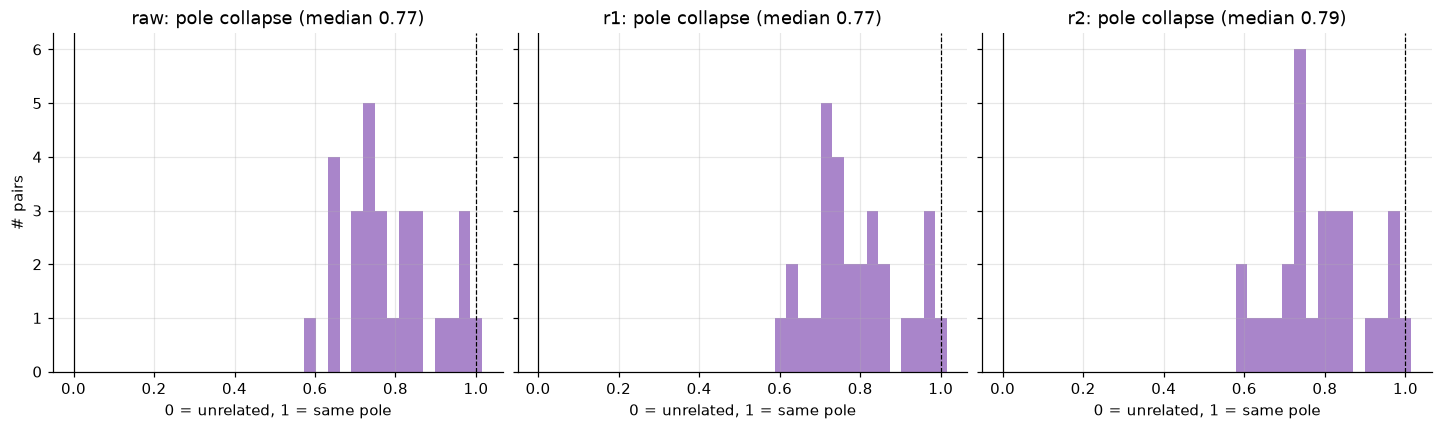

In [13]:
fig, axes = plt.subplots(1, len(MODES), figsize=(13, 3.8), sharey=True)
for ax, m in zip(axes, MODES):
    g = geo.filter(pl.col("mode") == m)
    ax.hist(g["pole_collapse"], bins=15, color="tab:purple", alpha=0.8)
    ax.axvline(0, color="k", lw=0.8); ax.axvline(1, color="k", lw=0.8, ls="--")
    ax.set_title(f"{m}: pole collapse (median {g['pole_collapse'].median():.2f})"); ax.set_xlabel("0 = unrelated, 1 = same pole")
axes[0].set_ylabel("# pairs")
plt.show()

## B. Minimal pairs

The two `minimal` headlines of a pair differ only by the direction words. Their cosine, next to (i)
same-pole headline pairs and (ii) headlines of different pairs, tells how much direction moves a
headline in embedding space compared with topic.

shape: (3, 5)
┌──────┬──────────────┬───────────┬────────────┬────────────┐
│ mode ┆ minimal_pair ┆ same_pole ┆ cross_pole ┆ other_pair │
│ ---  ┆ ---          ┆ ---       ┆ ---        ┆ ---        │
│ str  ┆ f64          ┆ f64       ┆ f64        ┆ f64        │
╞══════╪══════════════╪═══════════╪════════════╪════════════╡
│ r1   ┆ 0.772        ┆ 0.383     ┆ 0.403      ┆ 0.124      │
│ r2   ┆ 0.772        ┆ 0.382     ┆ 0.403      ┆ 0.124      │
│ raw  ┆ 0.834        ┆ 0.557     ┆ 0.572      ┆ 0.372      │
└──────┴──────────────┴───────────┴────────────┴────────────┘


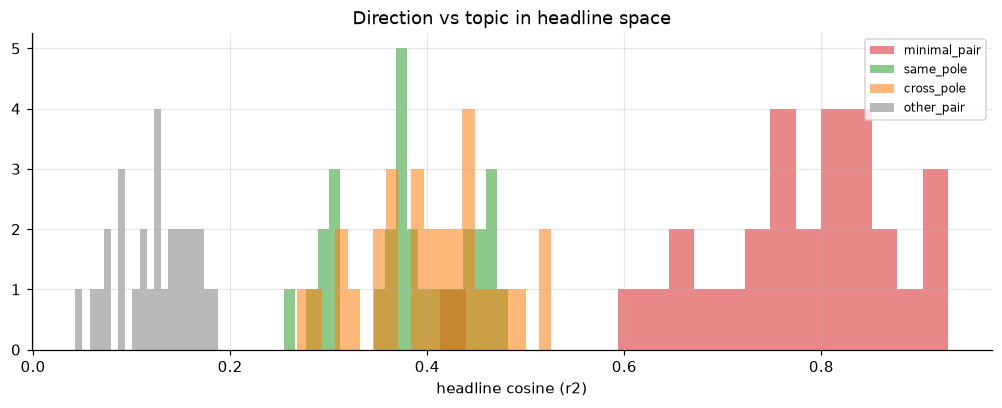

In [14]:
mp = []
for m in MODES:
    E = E_H[m]
    for pr in PAIR_ROWS:
        ids = H.filter(pl.col("pid") == pr["pid"])
        ia = ids.filter(pl.col("pole") == "A")["hid"].to_numpy(); ib = ids.filter(pl.col("pole") == "B")["hid"].to_numpy()
        ma = ids.filter((pl.col("pole") == "A") & (pl.col("kind") == "minimal"))["hid"][0]
        mb = ids.filter((pl.col("pole") == "B") & (pl.col("kind") == "minimal"))["hid"][0]
        other = H.filter(pl.col("pid") != pr["pid"])["hid"].to_numpy()
        mp.append(dict(mode=m, pair=pr["pair"], minimal_pair=float(E[ma] @ E[mb]),
                       same_pole=float(np.mean([(E[ia] @ E[ia].T)[np.triu_indices(len(ia), 1)].mean(),
                                                (E[ib] @ E[ib].T)[np.triu_indices(len(ib), 1)].mean()])),
                       cross_pole=float((E[ia] @ E[ib].T).mean()),
                       other_pair=float((E[np.r_[ia, ib]] @ E[other].T).mean())))
mp = pl.DataFrame(mp)
print(mp.group_by("mode").agg(pl.exclude("pair", "mode").mean().round(3)).sort("mode"))
fig, ax = plt.subplots(figsize=(9, 3.6))
g = mp.filter(pl.col("mode") == MAIN_MODE)
for col, c in (("minimal_pair", "tab:red"), ("same_pole", "tab:green"), ("cross_pole", "tab:orange"), ("other_pair", "0.5")):
    ax.hist(g[col], bins=20, alpha=0.55, label=col, color=c)
ax.legend(fontsize=8); ax.set_xlabel(f"headline cosine ({MAIN_MODE})"); ax.set_title("Direction vs topic in headline space")
plt.show()

## C. Pole contest: mean-top-K(correct) vs mean-top-K(opposite)

Per headline: `s_true`, `s_opp` = mean of the top-K primitive scores of each pole (paraphrases pooled
with the production rule first). Reported:

- **accuracy** = share with `s_true > s_opp` (50% = coin flip);
- **AUC** per pair of the signed score `d = s_A − s_B` separating pole-A from pole-B headlines
  (threshold-free: this is what a `sim(A) − sim(B)` signal would achieve);
- **margin** `s_true − s_opp` against the topic gap `max(s_true, s_opp) − median narrative score`:
  direction margin as a share of how strongly the topic was found.

In [15]:
def auc(pos, neg):
    x = np.r_[pos, neg]
    r = np.argsort(np.argsort(x)) + 1.0
    # average ranks for ties
    _, inv, cnt = np.unique(x, return_inverse=True, return_counts=True)
    sums = np.zeros(len(cnt)); np.add.at(sums, inv, r); r = (sums / cnt)[inv]
    n1, n0 = len(pos), len(neg)
    return (r[:n1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)


t_idx, o_idx = H["true_narr"].to_numpy(), H["opp_narr"].to_numpy()
ROWS = np.arange(H.height)
res = []
for (m, k), N in NS.items():
    s_t, s_o = N[ROWS, t_idx], N[ROWS, o_idx]
    med = np.median(N, axis=1)
    res.append(H.select("hid", "pid", "pair", "pole", "kind").with_columns(
        pl.lit(m).alias("mode"), pl.lit("all" if k is None else str(k)).alias("K"),
        pl.Series("s_true", s_t), pl.Series("s_opp", s_o), pl.Series("margin", s_t - s_o),
        pl.Series("topic_gap", np.maximum(s_t, s_o) - med),
        pl.Series("rank_true", (N > s_t[:, None]).sum(1) + 1), pl.Series("rank_opp", (N > s_o[:, None]).sum(1) + 1)))
res = pl.concat(res).with_columns((pl.col("margin") > 0).alias("correct"),
                                  (pl.col("margin") / pl.col("topic_gap")).alias("rel_margin"))

pair_auc = []
for (m, kk), g in res.group_by("mode", "K"):
    for pid, gp in g.group_by("pid"):
        d = np.where(gp["pole"] == "A", gp["margin"], -gp["margin"])     # d = s_A - s_B for every headline
        isA = (gp["pole"] == "A").to_numpy()
        pair_auc.append(dict(mode=m, K=kk, pid=pid[0], pair=gp["pair"][0], auc=auc(d[isA], d[~isA]),
                             acc=gp["correct"].mean()))
pair_auc = pl.DataFrame(pair_auc)

k_order = ["1", "2", "3", "5", "all"]
summary = (res.group_by("mode", "K").agg(pl.col("correct").mean().alias("accuracy"),
                                          pl.col("margin").median().alias("median_margin"),
                                          pl.col("rel_margin").median().alias("median_rel_margin"))
           .join(pair_auc.group_by("mode", "K").agg(pl.col("auc").median().alias("median_pair_auc"),
                                                    (pl.col("auc") >= 0.8).mean().alias("share_pairs_auc>=0.8")),
                 on=["mode", "K"])
           .with_columns(pl.col("K").cast(pl.Enum(k_order))).sort("mode", "K"))
summary.with_columns(pl.selectors.float().round(3))

mode,K,accuracy,median_margin,median_rel_margin,median_pair_auc,share_pairs_auc>=0.8
str,enum,f64,f32,f32,f64,f64
"""r1""","""1""",0.734,0.049,0.188,0.84,0.586
"""r1""","""2""",0.759,0.045,0.181,0.84,0.655
"""r1""","""3""",0.766,0.047,0.181,0.84,0.69
"""r1""","""5""",0.766,0.047,0.199,0.84,0.69
"""r1""","""all""",0.769,0.045,0.201,0.84,0.69
"""r2""","""1""",0.734,0.049,0.188,0.84,0.586
"""r2""","""2""",0.755,0.044,0.179,0.84,0.655
"""r2""","""3""",0.759,0.046,0.182,0.84,0.69
"""r2""","""5""",0.762,0.046,0.196,0.84,0.69


r2, K=3: accuracy 220/290 = 0.759 | 95% CI [0.710, 0.807] | two-sided binomial p vs 0.5 = 3.23e-19


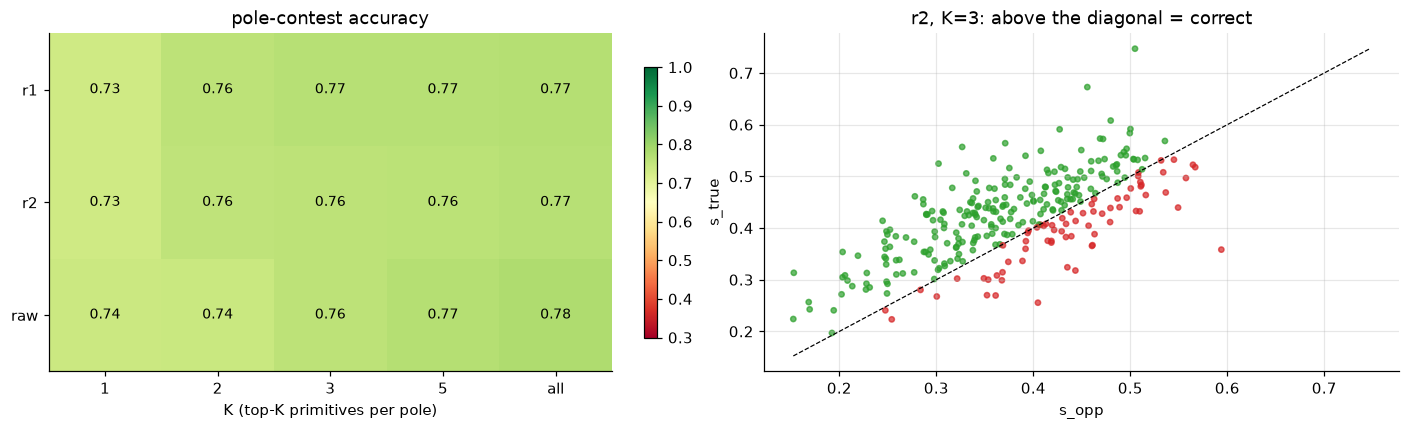

In [16]:
# binomial check against a coin flip for the main configuration
from math import comb
g = res.filter((pl.col("mode") == MAIN_MODE) & (pl.col("K") == str(K_MAIN)))
n, x = g.height, int(g["correct"].sum())
p_two = min(1.0, 2 * sum(comb(n, i) for i in range(max(x, n - x), n + 1)) / 2 ** n)
boot = [RNG.choice(g["correct"].to_numpy(), n).mean() for _ in range(5000)]
print(f"{MAIN_MODE}, K={K_MAIN}: accuracy {x}/{n} = {x / n:.3f} | 95% CI [{np.quantile(boot, .025):.3f}, "
      f"{np.quantile(boot, .975):.3f}] | two-sided binomial p vs 0.5 = {p_two:.2e}")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
acc = summary.pivot(on="K", index="mode", values="accuracy").select(["mode"] + k_order)
im = axes[0].imshow(acc.drop("mode").to_numpy(), cmap="RdYlGn", vmin=0.3, vmax=1.0)
axes[0].set_xticks(range(len(k_order)), k_order); axes[0].set_yticks(range(acc.height), acc["mode"])
for (i, j), v in np.ndenumerate(acc.drop("mode").to_numpy()):
    axes[0].text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9)
axes[0].set_xlabel("K (top-K primitives per pole)"); axes[0].set_title("pole-contest accuracy"); axes[0].grid(False)
plt.colorbar(im, ax=axes[0], shrink=0.8)
g = res.filter((pl.col("mode") == MAIN_MODE) & (pl.col("K") == str(K_MAIN)))
axes[1].scatter(g["s_opp"], g["s_true"], s=12, c=np.where(g["correct"], "tab:green", "tab:red"), alpha=0.7)
lo, hi = min(g["s_opp"].min(), g["s_true"].min()), max(g["s_opp"].max(), g["s_true"].max())
axes[1].plot([lo, hi], [lo, hi], "k--", lw=0.8)
axes[1].set_xlabel("s_opp"); axes[1].set_ylabel("s_true"); axes[1].set_title(f"{MAIN_MODE}, K={K_MAIN}: above the diagonal = correct")
plt.show()

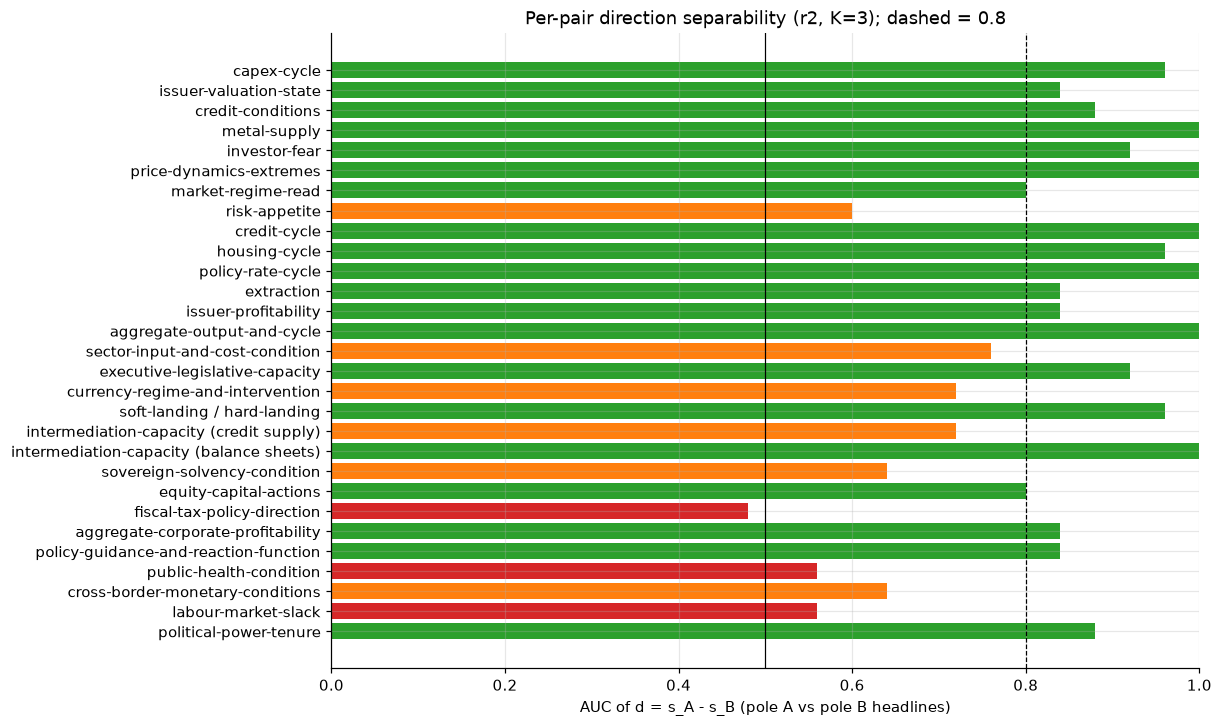

corr(pair AUC, pole_collapse) = -0.538


mode,K,pid,pair,auc,acc,pole_collapse,centroid_cos
str,str,i64,str,f64,f64,f64,f64
"""r2""","""3""",0,"""political-power-tenure""",0.88,0.8,0.75,0.763
"""r2""","""3""",1,"""labour-market-slack""",0.56,0.5,0.849,0.852
"""r2""","""3""",2,"""cross-border-monetary-conditions""",0.64,0.6,0.973,0.93
"""r2""","""3""",3,"""public-health-condition""",0.56,0.6,0.734,0.723
"""r2""","""3""",4,"""policy-guidance-and-reaction-function""",0.84,0.8,0.975,0.917
"""r2""","""3""",5,"""aggregate-corporate-profitability""",0.84,0.9,0.831,0.835
"""r2""","""3""",6,"""fiscal-tax-policy-direction""",0.48,0.3,0.913,0.876
"""r2""","""3""",7,"""equity-capital-actions""",0.8,0.8,0.66,0.687
"""r2""","""3""",8,"""sovereign-solvency-condition""",0.64,0.6,1.015,0.951


In [17]:
pa = pair_auc.filter((pl.col("mode") == MAIN_MODE) & (pl.col("K") == str(K_MAIN))).sort("auc")
pa = pa.join(geo.filter(pl.col("mode") == MAIN_MODE).select("pair", "pole_collapse", "centroid_cos"), on="pair")
fig, ax = plt.subplots(figsize=(11, 6.5))
ax.barh(pa["pair"], pa["auc"], color=np.where(pa["auc"] >= 0.8, "tab:green", np.where(pa["auc"] >= 0.6, "tab:orange", "tab:red")))
ax.axvline(0.5, color="k", lw=0.8); ax.axvline(0.8, color="k", lw=0.8, ls="--")
ax.set_xlim(0, 1); ax.set_xlabel("AUC of d = s_A - s_B (pole A vs pole B headlines)")
ax.set_title(f"Per-pair direction separability ({MAIN_MODE}, K={K_MAIN}); dashed = 0.8")
plt.show()
print("corr(pair AUC, pole_collapse) =", round(np.corrcoef(pa["auc"], pa["pole_collapse"])[0, 1], 3))
pa.with_columns(pl.selectors.float().round(3))

## D. By headline kind: does negation / opposite wording fade away?

If embeddings wash out negation, `negation` and `contrast` headlines (which carry the *opposite* pole's
vocabulary) should drop below 50%: the model follows the words, not the meaning.

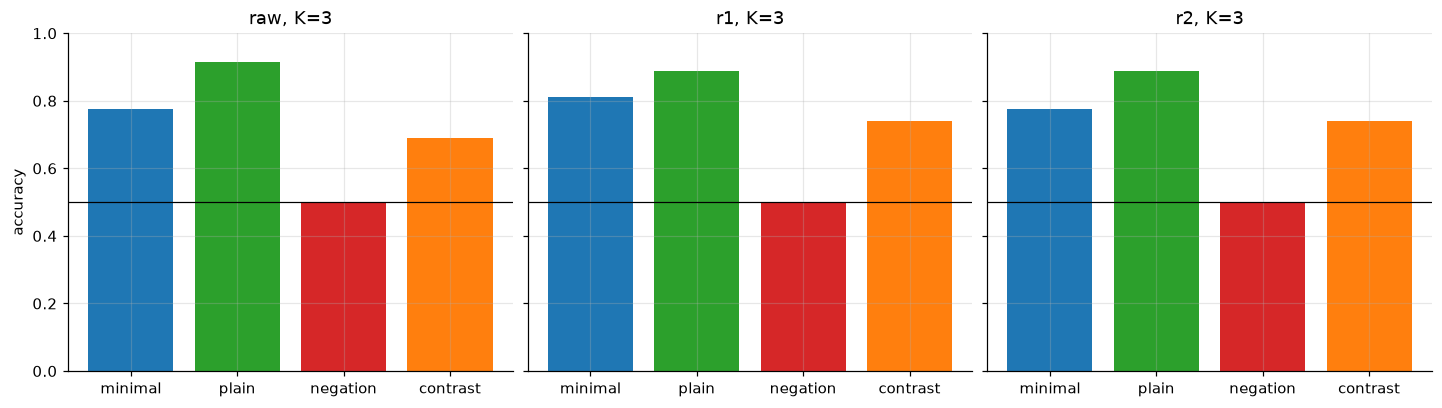

mode,minimal,plain,negation,contrast
str,f64,f64,f64,f64
"""r1""",0.810345,0.887931,0.5,0.741379
"""r2""",0.775862,0.887931,0.5,0.741379
"""raw""",0.775862,0.913793,0.5,0.689655


In [18]:
kind_tab = (res.group_by("mode", "K", "kind").agg(pl.col("correct").mean().alias("accuracy"),
                                                  pl.col("rel_margin").median().alias("median_rel_margin"), pl.len().alias("n"))
            .with_columns(pl.col("K").cast(pl.Enum(k_order))).sort("mode", "K", "kind"))
KIND_ORDER = ["minimal", "plain", "negation", "contrast"]
fig, axes = plt.subplots(1, len(MODES), figsize=(13, 3.6), sharey=True)
for ax, m in zip(axes, MODES):
    g = kind_tab.filter((pl.col("mode") == m) & (pl.col("K") == str(K_MAIN)))
    vals = [g.filter(pl.col("kind") == kd)["accuracy"][0] for kd in KIND_ORDER]
    ax.bar(KIND_ORDER, vals, color=["tab:blue", "tab:green", "tab:red", "tab:orange"])
    ax.axhline(0.5, color="k", lw=0.8); ax.set_ylim(0, 1); ax.set_title(f"{m}, K={K_MAIN}")
axes[0].set_ylabel("accuracy")
plt.show()
kind_tab.filter(pl.col("K") == str(K_MAIN)).pivot(on="kind", index="mode", values="accuracy").select(["mode"] + KIND_ORDER)

In [19]:
# the worst calls: opposite pole wins by the largest relative margin
(res.filter((pl.col("mode") == MAIN_MODE) & (pl.col("K") == str(K_MAIN)) & ~pl.col("correct"))
 .join(H.select("hid", "headline", "true_name", "opp_name"), on="hid")
 .sort("rel_margin").head(25)
 .select("pair", "kind", "headline", "true_name", "opp_name", "s_true", "s_opp", "rel_margin")
 .with_columns(pl.selectors.float().round(3)))

pair,kind,headline,true_name,opp_name,s_true,s_opp,rel_margin
str,str,str,str,str,f32,f32,f32
"""issuer-valuation-state""","""negation""","""Valuation discount narrows as stocks no longer trade at depressed multiples""","""valuation-re-rating""","""valuation-de-rating""",0.324,0.435,-0.656
"""equity-capital-actions""","""negation""","""Company suspends buyback program and plans new stock issuance""","""equity-issuance""","""share-buyback""",0.256,0.405,-0.633
"""public-health-condition""","""negation""","""Health officials say outbreak is no longer under control""","""public-health-deterioration""","""public-health-improvement""",0.358,0.594,-0.486
"""risk-appetite""","""negation""","""Safe-haven demand fades as investors no longer shun risk""","""risk-on-appetite""","""risk-off-flight""",0.299,0.368,-0.478
"""risk-appetite""","""contrast""","""Investors abandon equities and pile into Treasuries""","""risk-off-flight""","""risk-on-appetite""",0.303,0.349,-0.42
"""political-power-tenure""","""negation""","""No-confidence motion against chancellor defeated by wide margin""","""mandate-strengthening""","""mandate-weakening""",0.318,0.443,-0.41
"""issuer-profitability""","""negation""","""Nike results defy fears of a profit shortfall""","""earnings-beat""","""earnings-miss""",0.27,0.352,-0.397
"""extraction""","""negation""","""Saudi Arabia ends voluntary production cuts and lifts output""","""extraction-ramp-up""","""extraction-curtailment""",0.269,0.361,-0.39
"""market-regime-read""","""negation""","""Calm shattered as markets no longer range-bound""","""turbulent-market-read""","""calm-market-read""",0.308,0.362,-0.381


## E. Topic vs direction

Rank of the true and the opposite narrative among **all** narratives of the taxonomy. If the scorer is
topic-only, both land near the top together: topic found, direction coin-flipped.

In [20]:
g = res.filter(pl.col("K") == str(K_MAIN))
te = (g.group_by("mode").agg(
    pl.col("rank_true").median().alias("median_rank_true"),
    pl.col("rank_opp").median().alias("median_rank_opp"),
    (pl.col("rank_true") <= TOPN).mean().alias(f"true_in_top{TOPN}"),
    (pl.col("rank_opp") <= TOPN).mean().alias(f"opp_in_top{TOPN}"),
    ((pl.col("rank_true") <= TOPN) & (pl.col("rank_opp") <= TOPN)).mean().alias(f"both_in_top{TOPN}"),
    (pl.min_horizontal("rank_true", "rank_opp") == 1).mean().alias("a_pole_is_top1"),
    (pl.col("rank_true") == 1).mean().alias("true_is_top1")).sort("mode"))
print(f"{narr.height} narratives in the taxonomy, K={K_MAIN}")
te.with_columns(pl.selectors.float().round(3))

419 narratives in the taxonomy, K=3


mode,median_rank_true,median_rank_opp,true_in_top10,opp_in_top10,both_in_top10,a_pole_is_top1,true_is_top1
str,f64,f64,f64,f64,f64,f64,f64
"""r1""",2.0,4.0,0.931,0.721,0.693,0.541,0.441
"""r2""",2.0,4.0,0.928,0.724,0.697,0.548,0.448
"""raw""",2.0,4.0,0.938,0.721,0.7,0.59,0.479


## F. Production selection (candidate budget, optional τ)

Replays the production cut (`narrative_scoring.selection.select`) on this test set: per headline keep the
top `ceil((1−q)·P)` primitives (ties included; `≥ τ` if `TAU` is set; jump cut if the run used it), NaN the
rest, narrative = the run's aggregation (mean / median) over its surviving primitives. Outcome per headline:
only the true pole selected / both / only the opposite / neither. "both" is the leakage the weekly panel shows.


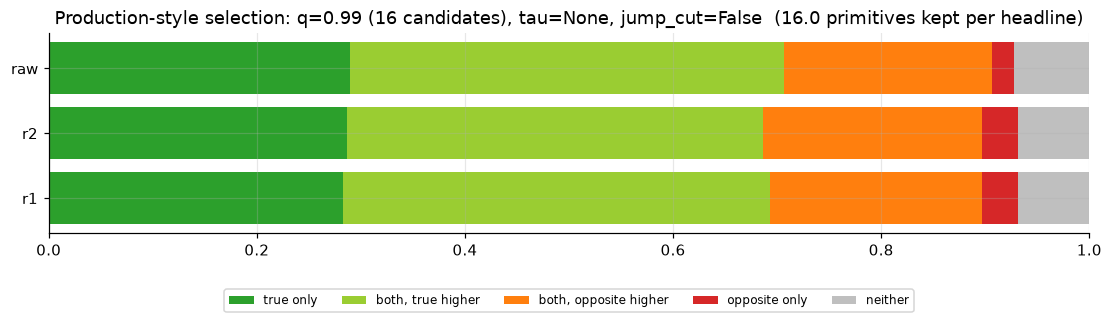

mode,true only,"both, true higher","both, opposite higher",opposite only,neither
str,f64,f64,f64,f64,f64
"""r1""",0.283,0.41,0.203,0.034,0.069
"""r2""",0.286,0.4,0.21,0.034,0.069
"""raw""",0.29,0.417,0.2,0.021,0.072


In [21]:
def tau_for(m):
    if TAU is None:
        return -np.inf
    return TAU[m] if isinstance(TAU, dict) else float(TAU)


N_CAND = n_candidates_for(Q_ROW, table.n_primitives)
nagg = np.nanmedian if CFG.narrative_agg is AggRule.MEDIAN else np.nanmean
sel = []
for m in MODES:
    s = select(S_PRIM[m], tau_for(m), N_CAND, jump_cut=CFG.jump_cut, jump_min_candidates=CFG.jump_min_candidates)
    S = np.full(S_PRIM[m].shape, np.nan)
    S[s.rows, s.cols] = s.vals
    kept = ~np.isnan(S)
    for i, r in enumerate(H.iter_rows(named=True)):
        ct, co = NARR_COLS[r["true_narr"]], NARR_COLS[r["opp_narr"]]
        st = nagg(S[i, ct]) if kept[i, ct].any() else np.nan
        so = nagg(S[i, co]) if kept[i, co].any() else np.nan
        if np.isnan(st) and np.isnan(so):
            out = "neither"
        elif np.isnan(so):
            out = "true only"
        elif np.isnan(st):
            out = "opposite only"
        else:
            out = "both, true higher" if st > so else "both, opposite higher"
        sel.append(dict(mode=m, hid=r["hid"], kind=r["kind"], outcome=out, n_kept=int(kept[i].sum())))
sel = pl.DataFrame(sel)
OUT = ["true only", "both, true higher", "both, opposite higher", "opposite only", "neither"]
tab = (sel.group_by("mode", "outcome").len().with_columns((pl.col("len") / H.height).alias("share"))
       .pivot(on="outcome", index="mode", values="share").fill_null(0.0))
tab = tab.select(["mode"] + [o for o in OUT if o in tab.columns]).sort("mode")
fig, ax = plt.subplots(figsize=(10, 2.8))
left = np.zeros(tab.height)
cols = {"true only": "tab:green", "both, true higher": "yellowgreen", "both, opposite higher": "tab:orange",
        "opposite only": "tab:red", "neither": "0.75"}
for o in OUT:
    if o in tab.columns:
        ax.barh(tab["mode"], tab[o], left=left, color=cols[o], label=o); left += tab[o].to_numpy()
ax.legend(fontsize=8, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.25)); ax.set_xlim(0, 1)
ax.set_title(f"Production-style selection: q={Q_ROW} ({N_CAND} candidates), tau={TAU}, jump_cut={CFG.jump_cut}  ({sel['n_kept'].mean():.1f} primitives kept per headline)")
plt.show()
tab.with_columns(pl.selectors.float().round(3))

## Verdict

In [22]:
k = str(K_MAIN)
s = summary.filter((pl.col("mode") == MAIN_MODE) & (pl.col("K") == k)).row(0, named=True)
kt = {r["kind"]: r["accuracy"] for r in kind_tab.filter((pl.col("mode") == MAIN_MODE) & (pl.col("K") == k)).iter_rows(named=True)}
gm = geo.filter(pl.col("mode") == MAIN_MODE)
mm = mp.filter(pl.col("mode") == MAIN_MODE)
tm = te.filter(pl.col("mode") == MAIN_MODE).row(0, named=True)
sm = {r["outcome"]: r["len"] / H.height for r in sel.filter(pl.col("mode") == MAIN_MODE).group_by("outcome").len().iter_rows(named=True)}

print(f"configuration: {MAIN_MODE}, paraphrase pooling = {PARAPHRASE_POOLING}, pole score = mean top-{k}\n")
print(f"A  primitive geometry : median pole collapse {gm['pole_collapse'].median():.2f} "
      f"(0 = poles as far apart as unrelated narratives, 1 = indistinguishable)")
print(f"B  minimal pairs      : cos {mm['minimal_pair'].mean():.3f} vs same-pole {mm['same_pole'].mean():.3f} "
      f"vs other pairs {mm['other_pair'].mean():.3f}")
print(f"C  pole contest       : accuracy {s['accuracy']:.3f} | median pair AUC {s['median_pair_auc']:.3f} | "
      f"pairs with AUC >= 0.8: {s['share_pairs_auc>=0.8']:.0%} | median rel. margin {s['median_rel_margin']:.3f}")
print(f"D  by kind            : " + " | ".join(f"{kd} {kt.get(kd, float('nan')):.2f}" for kd in KIND_ORDER))
print(f"E  topic vs direction : both poles in top-{TOPN} for {tm[f'both_in_top{TOPN}']:.0%} of headlines; "
      f"a pole is top-1 for {tm['a_pole_is_top1']:.0%}, the true pole for {tm['true_is_top1']:.0%}")
print(f"F  production select  : " + " | ".join(f"{o} {sm.get(o, 0):.0%}" for o in OUT))

print("\nrule of thumb for the pair AUC: >= 0.8 direction recoverable from sim(A) - sim(B); "
      "0.6-0.8 weak, needs a second signal; < 0.6 topic-only.")
if SAVE_DIR:
    SAVE_DIR = Path(SAVE_DIR); SAVE_DIR.mkdir(parents=True, exist_ok=True)
    for name, df in (("headline_scores", res), ("pair_auc", pair_auc), ("geometry", geo), ("minimal_pairs", mp),
                     ("selection", sel), ("test_set", H.drop("true_narr", "opp_narr"))):
        df.write_parquet(SAVE_DIR / f"{name}.parquet")
    print("tables written to", SAVE_DIR)

configuration: r2, paraphrase pooling = max, pole score = mean top-3

A  primitive geometry : median pole collapse 0.79 (0 = poles as far apart as unrelated narratives, 1 = indistinguishable)
B  minimal pairs      : cos 0.772 vs same-pole 0.382 vs other pairs 0.124
C  pole contest       : accuracy 0.759 | median pair AUC 0.840 | pairs with AUC >= 0.8: 69% | median rel. margin 0.182
D  by kind            : minimal 0.78 | plain 0.89 | negation 0.50 | contrast 0.74
E  topic vs direction : both poles in top-10 for 70% of headlines; a pole is top-1 for 55%, the true pole for 45%
F  production select  : true only 29% | both, true higher 40% | both, opposite higher 21% | opposite only 3% | neither 7%

rule of thumb for the pair AUC: >= 0.8 direction recoverable from sim(A) - sim(B); 0.6-0.8 weak, needs a second signal; < 0.6 topic-only.
